In [1]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rpy2.robjects.conversion import localconverter
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# single cell
import anndata as ad
import scanpy as sc

# custom
sys.path.insert(0, '../..')
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from utils import *

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

CORES = 10
DATADIR = Path("../../../data") / "processed" / "single_cell" / "combined"
REFDIR = Path("../../../references")
SUBSETS_DIR = DATADIR / "subsets"

METADATA = [
    "Diet",
    "Age",
    "Depot",
    "Sex",
]
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
GLOBAL_INT_KEY = "global_INT_scvi-hvg-Identifier"

%load_ext autoreload
%load_ext rpy2.ipython
%matplotlib inline
converter = get_converter()
# R_preload()
mpl.rcdefaults()
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Click 9.1. Use feature detection or 'importlib.metadata.version("click")' instead.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12

# Subset mac/fib pops

In [2]:
adata_fibro = sc.read_h5ad(SUBSETS_DIR / "fibro.h5ad")
adata_macro = sc.read_h5ad(SUBSETS_DIR / "macro.h5ad")
adata = sc.read_h5ad(DATADIR / "eWAT_Male.h5ad")

In [7]:
filtered = adata_fibro.obs_names.tolist() + adata_macro.obs_names.tolist()
assert sum(adata.obs_names.isin(filtered)) == len(filtered)
adata = adata[filtered]

In [ ]:
adata.obs["celltype_hires"] = None
adata.obs.loc[adata_fibro.obs_names.tolist(), "celltype_hires"] = "fibro_" + adata_fibro.obs["leiden_fibro_0.6"].astype(str)
adata.obs.loc[adata_macro.obs_names.tolist(), "celltype_hires"] = "macro_" + adata_macro.obs["leiden_macro_0.4"].astype(str)
# order_obs(adata, "celltype_hires", np.sort(adata.obs["celltype_hires"].unique()))

TypeError: '<' not supported between instances of 'str' and 'NoneType'

In [24]:
cleaned_filter = adata.obs["celltype"].isin(["Macrophage", "Fibroblast"]) & adata.obs["celltype_hires"].isna()
adata[cleaned_filter]

View of AnnData object with n_obs × n_vars = 23451 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'celltype_hires', 'celltype_hires_named'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 

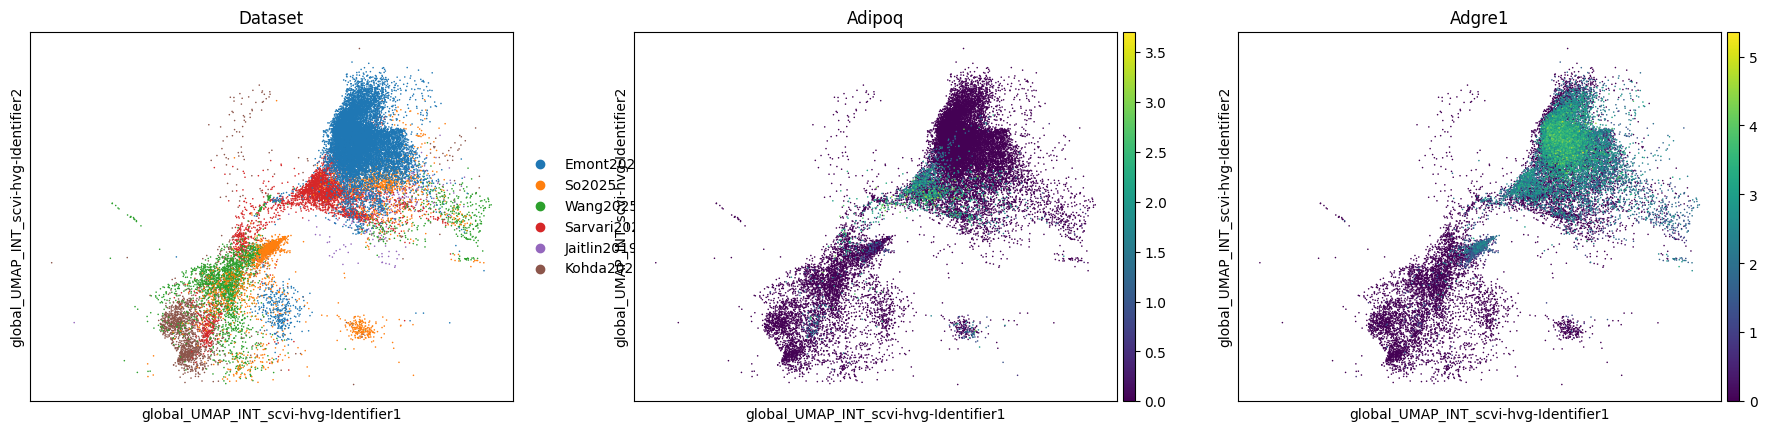

In [34]:
sc.pl.embedding(adata[cleaned_filter], "global_UMAP_INT_scvi-hvg-Identifier", color=["Dataset", "Adipoq", "Adgre1"], layer="normalized")

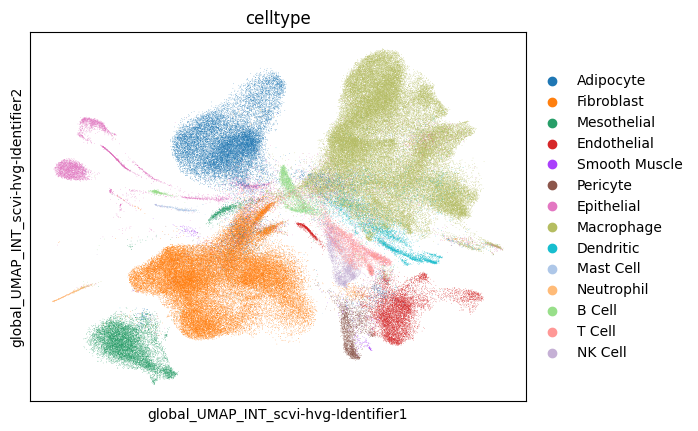

In [ ]:
sc.pl.embedding(adata, "global_UMAP_INT_scvi-hvg-Identifier", color="celltype")

# Rename final subsets

In [4]:
adata.obs["celltype_hires_named"] = adata.obs["celltype_hires"].map({
    "fibro_0" : "Progenitor",
    "fibro_1" : "N-ASC 2",
    "fibro_2" : "ASC 1",
    "fibro_3" : "N-ASC 3",
    "fibro_4" : "N-ASC 1",
    "fibro_5" : "Septal FBs",
    "fibro_6" : "ASC 2",
    "fibro_8" : "Dividing FB",
    "macro_0" : "LAM",
    "macro_1" : "VAM-Lipo",
    "macro_2" : "Monos",
    "macro_3" : "pre-LAM",
    "macro_4" : "VAM",
    "macro_5" : "Dividing Mac",
    "macro_6" : "Reg-Macs",
})

order_obs(
    adata, "celltype_hires_named",
    ['Progenitor', 'ASC 1', 'ASC 2', 'N-ASC 1', 'N-ASC 2', 'N-ASC 3', 'Septal FBs', 'Dividing FB',
     'VAM', 'VAM-Lipo', 'pre-LAM', 'LAM', 'Reg-Macs', 'Monos', 'Dividing Mac'])

# Save/Load

In [5]:
adata.write(DATADIR / "eWAT_Male.h5ad")
adata

... storing 'celltype_hires' as categorical


AnnData object with n_obs × n_vars = 191104 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'celltype_hires', 'celltype_hires_named'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_

In [4]:
adata = sc.read_h5ad(DATADIR / "eWAT_Male-fb_macs.h5ad")
adata

AnnData object with n_obs × n_vars = 100798 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'celltype_hires'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_v